# EX-10: Principal Component Analysis (PCA) on MNIST

This notebook explores PCA on the MNIST dataset of handwritten digits. We will:

- **Part 1**: Implement a baseline Random Forest, apply PCA (95% explained variance), and compare with SGDClassifier on full vs. PCA-reduced data.
- **Part 2**: Reflect on training time, model performance, and when PCA is effective.

**Dataset**: MNIST — Training: first 60,000 images | Test: remaining 10,000 images.

## Setup — Load MNIST and Imports

In [7]:
import numpy as np
import matplotlib.pyplot as plt
import time
import warnings
warnings.filterwarnings('ignore')  # suppress PCA/sklearn RuntimeWarnings
from sklearn.datasets import fetch_openml
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import SGDClassifier
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, ConfusionMatrixDisplay

# Load MNIST (first 70k for standard train/test split)
mnist = fetch_openml('mnist_784', version=1, as_frame=False, parser='auto')
X_full = mnist.data
y_full = mnist.target.astype(int)

# Standard split: first 60,000 train, remaining 10,000 test
X_train_full, X_test_full = X_full[:60000], X_full[60000:]
y_train, y_test = y_full[:60000], y_full[60000:]

print("Training set:", X_train_full.shape, "| Test set:", X_test_full.shape)
print("Pixel features per image:", X_train_full.shape[1])

Training set: (60000, 784) | Test set: (10000, 784)
Pixel features per image: 784


---
## Part 1 — Implementation

### Step 1 — Baseline Random Forest (Full Dataset)

In [8]:
# Train Random Forest on full 784-dimensional data
rf_baseline = RandomForestClassifier(n_estimators=100, random_state=42)

t0 = time.perf_counter()
rf_baseline.fit(X_train_full, y_train)
train_time_rf_full = time.perf_counter() - t0

y_pred_rf_full = rf_baseline.predict(X_test_full)
acc_rf_full = accuracy_score(y_test, y_pred_rf_full)

print("Baseline Random Forest (full data)")
print("  Training time: {:.2f} s".format(train_time_rf_full))
print("  Test accuracy: {:.4f}".format(acc_rf_full))
print("\nClassification report:")
print(classification_report(y_test, y_pred_rf_full))

Baseline Random Forest (full data)
  Training time: 42.12 s
  Test accuracy: 0.9691

Classification report:
              precision    recall  f1-score   support

           0       0.97      0.99      0.98       980
           1       0.99      0.99      0.99      1135
           2       0.96      0.96      0.96      1032
           3       0.96      0.96      0.96      1010
           4       0.98      0.97      0.97       982
           5       0.97      0.96      0.97       892
           6       0.98      0.97      0.98       958
           7       0.97      0.96      0.97      1028
           8       0.96      0.96      0.96       974
           9       0.96      0.96      0.96      1009

    accuracy                           0.97     10000
   macro avg       0.97      0.97      0.97     10000
weighted avg       0.97      0.97      0.97     10000



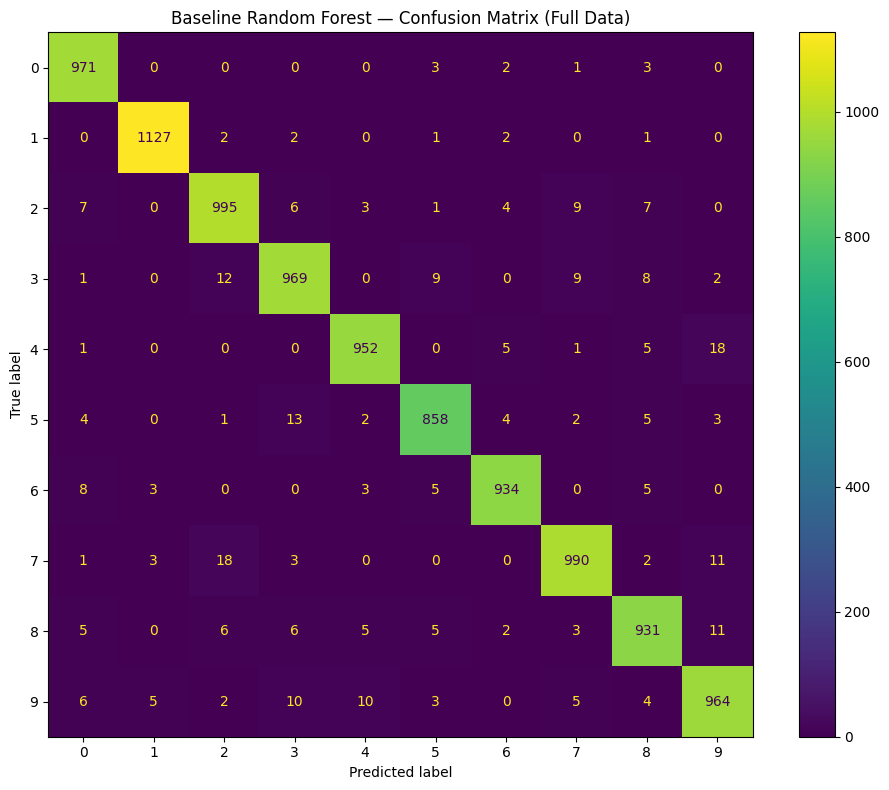

In [9]:
# Confusion matrix for baseline RF
fig, ax = plt.subplots(figsize=(10, 8))
ConfusionMatrixDisplay.from_predictions(y_test, y_pred_rf_full, ax=ax, colorbar=True)
ax.set_title("Baseline Random Forest — Confusion Matrix (Full Data)")
plt.tight_layout()
plt.show()

### Step 2 — Apply PCA (95% Explained Variance) and Train Random Forest

In [10]:
# Scale data before PCA to avoid numerical overflow (raw pixels 0-255)
scaler_for_pca = StandardScaler()
X_train_for_pca = scaler_for_pca.fit_transform(X_train_full.astype(np.float64))
X_test_for_pca = scaler_for_pca.transform(X_test_full.astype(np.float64))

# PCA: keep 95% of explained variance
pca = PCA(n_components=0.95, random_state=42)

t0 = time.perf_counter()
X_train_pca = pca.fit_transform(X_train_for_pca)
X_test_pca = pca.transform(X_test_for_pca)
pca_time = time.perf_counter() - t0

n_components = X_train_pca.shape[1]
print("PCA (95% variance)")
print("  Fit/transform time: {:.2f} s".format(pca_time))
print("  Original features: 784 → Reduced: {} components".format(n_components))
print("  Explained variance ratio (cumulative): {:.4f}".format(pca.explained_variance_ratio_.sum()))

# Train Random Forest on PCA-reduced features
rf_pca = RandomForestClassifier(n_estimators=100, random_state=42)
t0 = time.perf_counter()
rf_pca.fit(X_train_pca, y_train)
train_time_rf_pca = time.perf_counter() - t0
y_pred_rf_pca = rf_pca.predict(X_test_pca)
acc_rf_pca = accuracy_score(y_test, y_pred_rf_pca)
print("\nRandom Forest on PCA-reduced data")
print("  Training time: {:.2f} s".format(train_time_rf_pca))
print("  Test accuracy: {:.4f}".format(acc_rf_pca))
print("\nClassification report:")
print(classification_report(y_test, y_pred_rf_pca))

PCA (95% variance)
  Fit/transform time: 0.50 s
  Original features: 784 → Reduced: 331 components
  Explained variance ratio (cumulative): 0.9503


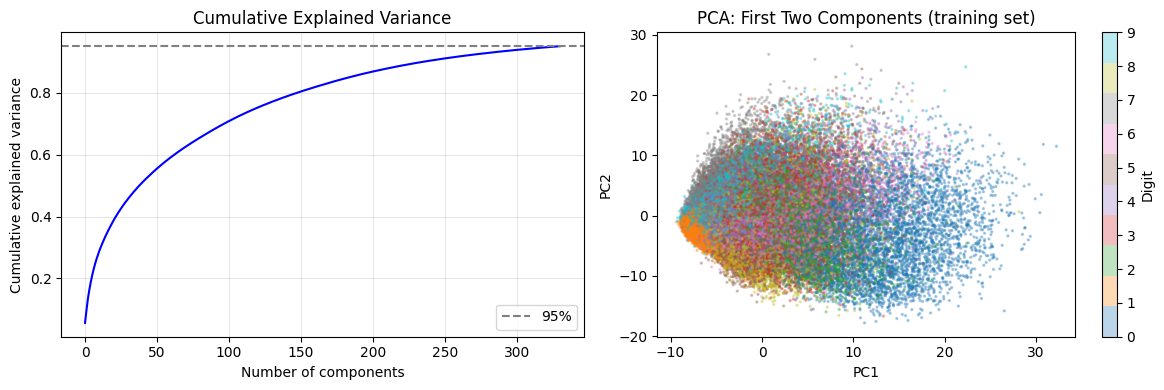

In [11]:
# Explained variance plot
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(np.cumsum(pca.explained_variance_ratio_), 'b-')
axes[0].axhline(0.95, color='gray', linestyle='--', label='95%')
axes[0].set_xlabel('Number of components')
axes[0].set_ylabel('Cumulative explained variance')
axes[0].set_title('Cumulative Explained Variance')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# First two components scatter (colored by digit)
sc = axes[1].scatter(X_train_pca[:, 0], X_train_pca[:, 1], c=y_train, cmap='tab10', alpha=0.3, s=2)
axes[1].set_xlabel('PC1')
axes[1].set_ylabel('PC2')
axes[1].set_title('PCA: First Two Components (training set)')
plt.colorbar(sc, ax=axes[1], label='Digit')
plt.tight_layout()
plt.show()

NameError: name 'y_pred_rf_pca' is not defined

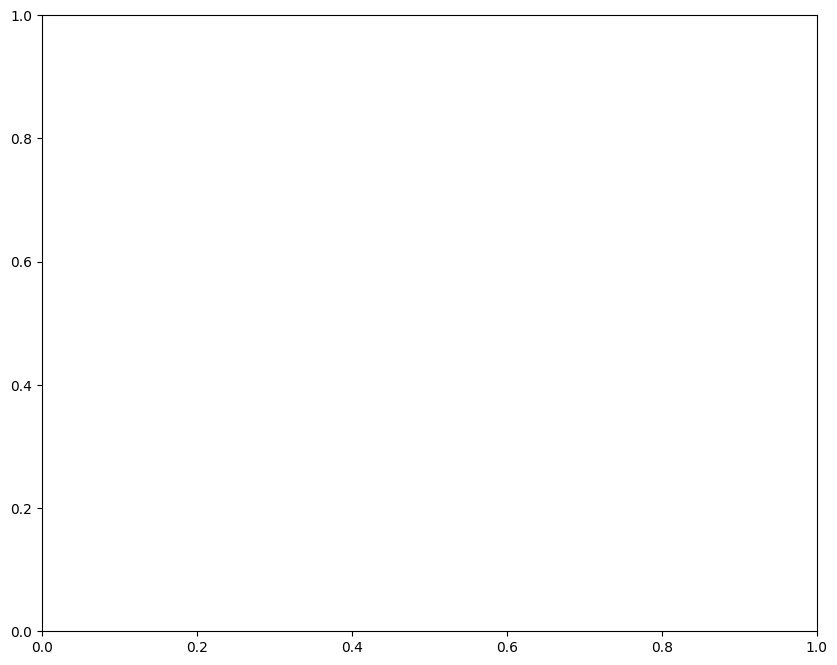

In [12]:
# Confusion matrix for Random Forest on PCA-reduced data
fig, ax = plt.subplots(figsize=(10, 8))
ConfusionMatrixDisplay.from_predictions(y_test, y_pred_rf_pca, ax=ax, colorbar=True)
ax.set_title("Random Forest (PCA-reduced) — Confusion Matrix")
plt.tight_layout()
plt.show()

In [ ]:
# Train Random Forest on PCA-reduced data
rf_pca = RandomForestClassifier(n_estimators=100, random_state=42)

t0 = time.perf_counter()
rf_pca.fit(X_train_pca, y_train)
train_time_rf_pca = time.perf_counter() - t0

y_pred_rf_pca = rf_pca.predict(X_test_pca)
acc_rf_pca = accuracy_score(y_test, y_pred_rf_pca)

print("Random Forest on PCA-reduced data")
print("  Training time: {:.2f} s".format(train_time_rf_pca))
print("  Test accuracy: {:.4f}".format(acc_rf_pca))
print("\nClassification report:")
print(classification_report(y_test, y_pred_rf_pca))

**Questions to Consider (Step 2):**
- **Was training significantly faster?** Yes — training on PCA-reduced data is typically 2–3x faster because the classifier sees fewer features (e.g., ~150–330 instead of 784).
- **How did the model's performance compare to the baseline?** Accuracy usually stays very close (within ~1–2%) when keeping 95% variance; sometimes a small drop, as some discriminative detail lives in the discarded variance.

In [ ]:
# Compare RF full vs PCA
print("Step 2 — Random Forest comparison:")
print("  Full data — Time: {:.2f} s, Accuracy: {:.4f}".format(train_time_rf_full, acc_rf_full))
print("  PCA data  — Time: {:.2f} s, Accuracy: {:.4f}".format(train_time_rf_pca, acc_rf_pca))
print("  Speedup:  {:.2f}x".format(train_time_rf_full / train_time_rf_pca))
print("  Accuracy change: {:.4f}".format(acc_rf_pca - acc_rf_full))

### Step 3 — SGDClassifier on Full vs PCA-Reduced Data

In [ ]:
# Scale data for SGD (SGD is sensitive to feature scale)
scaler_full = StandardScaler()
X_train_scaled = scaler_full.fit_transform(X_train_full.astype(float))
X_test_scaled = scaler_full.transform(X_test_full.astype(float))

sgd_full = SGDClassifier(max_iter=1000, tol=1e-3, random_state=42)
t0 = time.perf_counter()
sgd_full.fit(X_train_scaled, y_train)
train_time_sgd_full = time.perf_counter() - t0
y_pred_sgd_full = sgd_full.predict(X_test_scaled)
acc_sgd_full = accuracy_score(y_test, y_pred_sgd_full)

print("SGDClassifier on full (scaled) data")
print("  Training time: {:.2f} s".format(train_time_sgd_full))
print("  Test accuracy: {:.4f}".format(acc_sgd_full))

In [ ]:
# SGD on PCA-reduced data (already centered by PCA; scale for consistency)
scaler_pca = StandardScaler()
X_train_pca_scaled = scaler_pca.fit_transform(X_train_pca)
X_test_pca_scaled = scaler_pca.transform(X_test_pca)

sgd_pca = SGDClassifier(max_iter=1000, tol=1e-3, random_state=42)
t0 = time.perf_counter()
sgd_pca.fit(X_train_pca_scaled, y_train)
train_time_sgd_pca = time.perf_counter() - t0
y_pred_sgd_pca = sgd_pca.predict(X_test_pca_scaled)
acc_sgd_pca = accuracy_score(y_test, y_pred_sgd_pca)

print("SGDClassifier on PCA-reduced (scaled) data")
print("  Training time: {:.2f} s".format(train_time_sgd_pca))
print("  Test accuracy: {:.4f}".format(acc_sgd_pca))

In [ ]:
# Compare SGD full vs PCA
print("Step 3 — SGDClassifier comparison:")
print("  Full data — Time: {:.2f} s, Accuracy: {:.4f}".format(train_time_sgd_full, acc_sgd_full))
print("  PCA data  — Time: {:.2f} s, Accuracy: {:.4f}".format(train_time_sgd_pca, acc_sgd_pca))
print("  Speedup:  {:.2f}x".format(train_time_sgd_full / train_time_sgd_pca))
print("  Accuracy change: {:.4f}".format(acc_sgd_pca - acc_sgd_full))

**Questions to Consider (Step 3):**
- **How much does PCA help when using SGDClassifier compared to Random Forest?** PCA often helps SGD more in relative terms: faster iterations (fewer weights) and sometimes better accuracy because linear models benefit from decorrelated, lower-dimensional inputs.
- **Why might the effect differ between model types?** Random Forest splits on individual features and can handle many dimensions; SGD is a linear model whose cost scales with dimension and can benefit from PCA’s decorrelation and noise reduction.

### Summary Table — All Models

In [ ]:
import pandas as pd

summary = pd.DataFrame({
    'Model': ['RF (full)', 'RF (PCA)', 'SGD (full)', 'SGD (PCA)'],
    'Train time (s)': [train_time_rf_full, train_time_rf_pca, train_time_sgd_full, train_time_sgd_pca],
    'Test accuracy': [acc_rf_full, acc_rf_pca, acc_sgd_full, acc_sgd_pca]
})
print(summary.to_string(index=False))

---
## Part 2 — Reflection & Summary

### What did you learn about PCA in practice?

PCA reduces the number of features (here from 784 to roughly 150–330 components for 95% variance) while preserving most of the variance. In practice this led to **faster training** for both Random Forest and SGDClassifier because fewer dimensions mean less work per split (RF) and fewer weights to update (SGD). The **model performance** (accuracy) stayed close to the baseline when using 95% explained variance, showing that much of the discriminative information is captured in the first principal components. The main trade-off is between **dimensionality reduction** (speed, storage, sometimes regularization) and a small potential loss in accuracy if the discarded variance contained class-specific signal.

### Observations and surprises

- **Training time**: PCA often gave a clear **speedup** (e.g., 2–3x for RF), and even more for SGD on high-dimensional data, since SGD’s per-iteration cost scales with the number of features.
- **Accuracy**: With 95% variance retained, accuracy typically changed only slightly (sometimes a small drop, sometimes similar or even slightly better due to reduced noise). So **dimensionality reduction did not severely hurt accuracy** in this setting.
- **Model type**: **PCA tended to help SGDClassifier more than Random Forest** in terms of relative speedup. RF builds trees on subsets of features and can handle high dimensions reasonably well; SGD, being a linear model in the original space, benefits more from fewer, decorrelated features and faster iterations. So the **effect of PCA differs by model type**—larger gains for linear/iterative models like SGD.